Extracting BDF parameters from C:\Users\enneh\ds002778\sub-pd26\ses-off\eeg\sub-pd26_ses-off_task-rest_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 97791  =      0.000 ...   190.998 secs...
Using matplotlib as 2D backend.


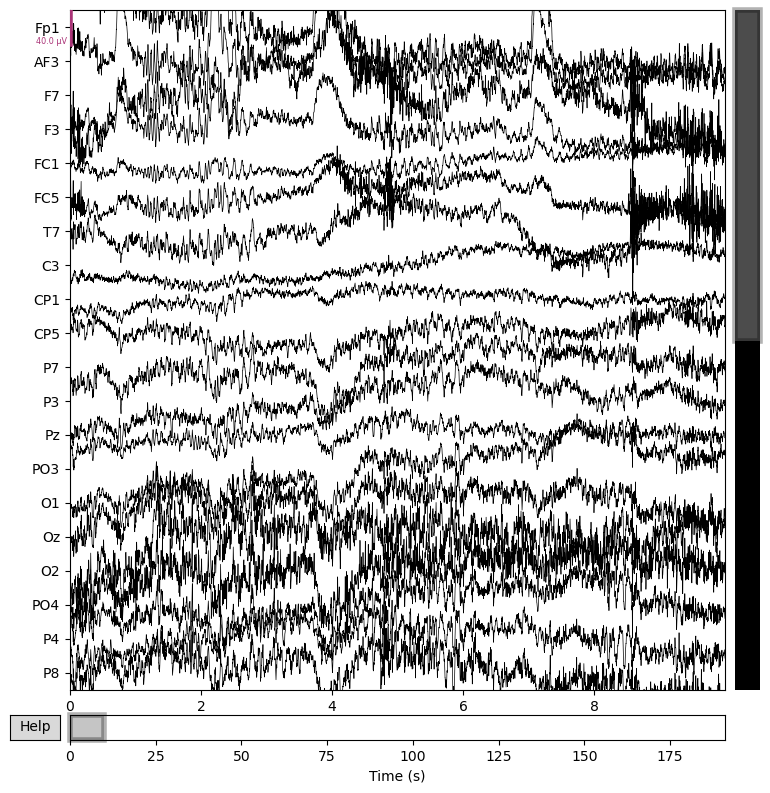

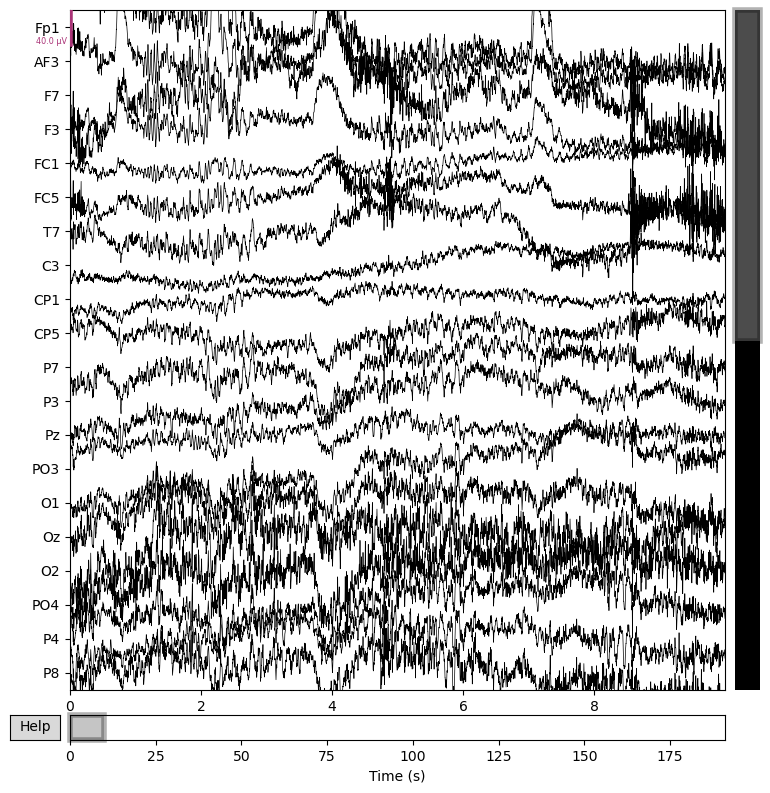

In [1]:
import mne

file_path = r"C:\Users\enneh\ds002778\sub-pd26\ses-off\eeg\sub-pd26_ses-off_task-rest_eeg.bdf"

raw = mne.io.read_raw_bdf(file_path, preload=True)
raw.plot()


In [2]:
print(raw)
print(raw.info['sfreq'])
print(raw.ch_names)


<RawBDF | sub-pd26_ses-off_task-rest_eeg.bdf, 41 x 97792 (191.0 s), ~30.6 MiB, data loaded>
512.0
['Fp1', 'AF3', 'F7', 'F3', 'FC1', 'FC5', 'T7', 'C3', 'CP1', 'CP5', 'P7', 'P3', 'Pz', 'PO3', 'O1', 'Oz', 'O2', 'PO4', 'P4', 'P8', 'CP6', 'CP2', 'C4', 'T8', 'FC6', 'FC2', 'F4', 'F8', 'AF4', 'Fp2', 'Fz', 'Cz', 'EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG5', 'EXG6', 'EXG7', 'EXG8', 'Status']


In [3]:
import mne
from mne.preprocessing import ICA
import numpy as np

In [4]:
def load_eeg_data(file_path):
    raw = mne.io.read_raw_bdf(file_path, preload=True)  # Adjust the path to your actual file
    return raw

In [5]:
def set_montage(raw_data):
    montage = mne.channels.make_standard_montage('biosemi32')
    montage.plot()
    raw_data.set_montage(montage, on_missing='warn')

In [6]:
def bandpass_filter(raw_data, l_freq=0.5, h_freq=50.0):
    raw_data.filter(l_freq=l_freq, h_freq=h_freq)
    return raw_data

In [7]:
def find_ecg_via_temporal_channels(ica, raw_data):
   
    ecg_indices, ecg_scores = ica.find_bads_ecg(raw_data, ch_name='T7')
    ica.exclude += ecg_indices  
    return ica

In [8]:
def apply_ica(raw_data, n_components=32):
    ica = ICA(n_components=n_components, random_state=97, max_iter="auto")
    ica.fit(raw_data)
    
    # Detect artifacts
    eog_indices, _ = ica.find_bads_eog(raw_data,ch_name=['Fp2', 'F8'],threshold=1.96)  


    # Mark components for removal
    ica.exclude = eog_indices
    # Experimental ECG detection
    ica = find_ecg_via_temporal_channels(ica, raw_data)
    
    # Apply ICA to remove artifacts
    raw_data = ica.apply(raw_data)
    return raw_data

In [9]:
def segment_data(raw_data, duration=1.0):
    events = mne.make_fixed_length_events(raw_data, duration=duration)
    epochs = mne.Epochs(raw_data, events, tmin=0, tmax=duration, baseline=None, preload=True)
    eeg_data = epochs.get_data()  # Shape should be (180, 32, 512) if 3 mins, 32 channels, 512 samples/s
    return eeg_data

In [10]:
raw = load_eeg_data(file_path)
raw

Extracting BDF parameters from C:\Users\enneh\ds002778\sub-pd26\ses-off\eeg\sub-pd26_ses-off_task-rest_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 97791  =      0.000 ...   190.998 secs...


<RawBDF | sub-pd26_ses-off_task-rest_eeg.bdf, 41 x 97792 (191.0 s), ~30.6 MiB, data loaded>

In [11]:
raw.crop(tmax=180.)
raw = raw.drop_channels(['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG5', 'EXG6', 'EXG7', 'EXG8', 'Status'])

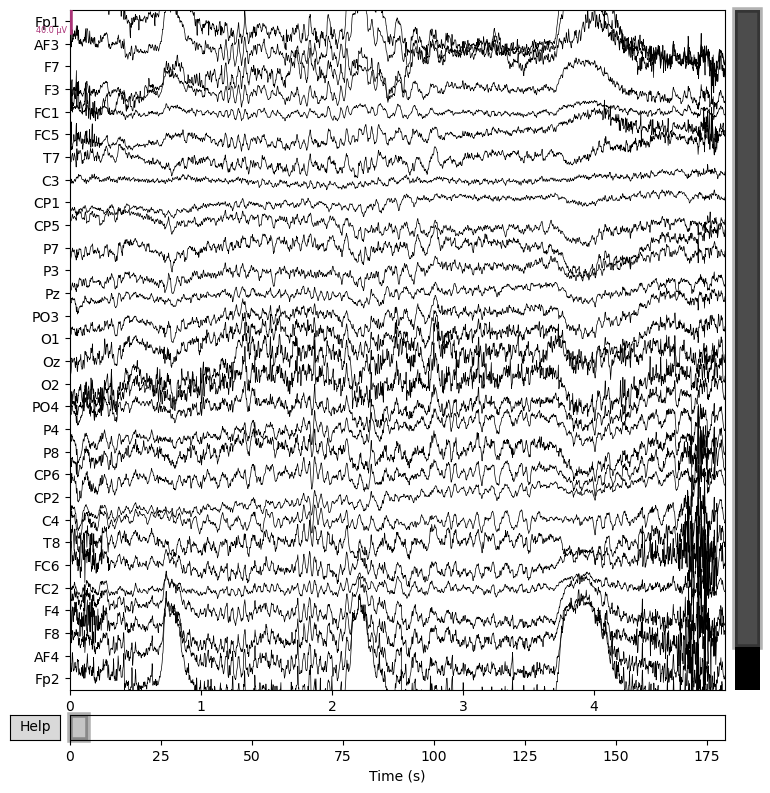

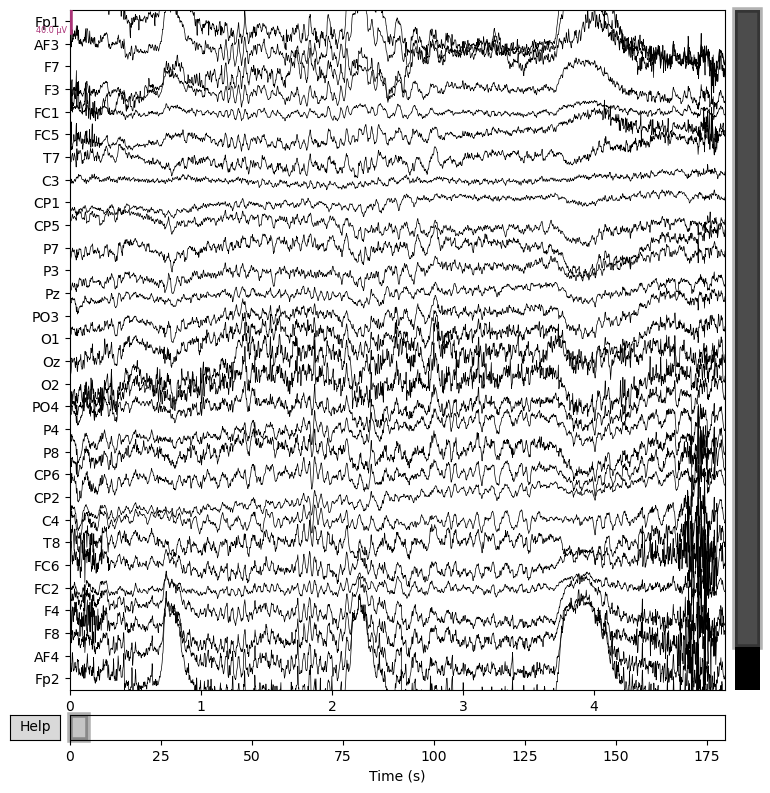

In [12]:
raw.plot(duration=5, n_channels=30)

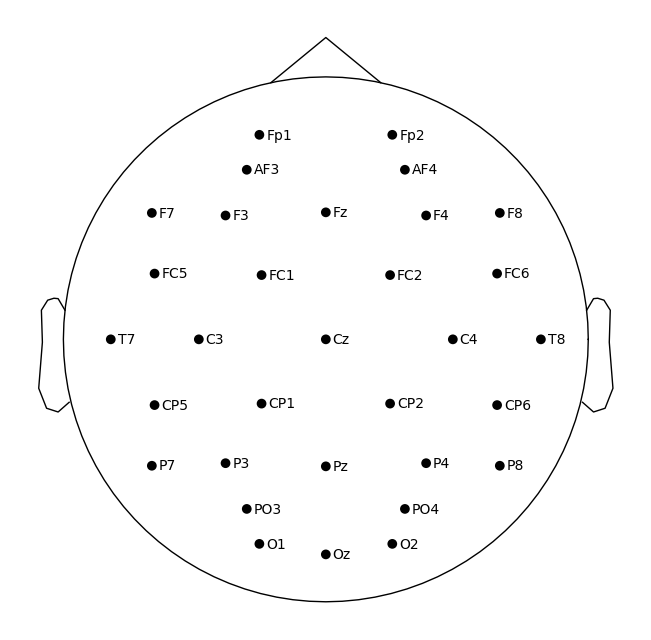

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 50 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 50.00 Hz
- Upper transition bandwidth: 12.50 Hz (-6 dB cutoff frequency: 56.25 Hz)
- Filter length: 3381 samples (6.604 s)



In [13]:
set_montage(raw)
raw = bandpass_filter(raw)

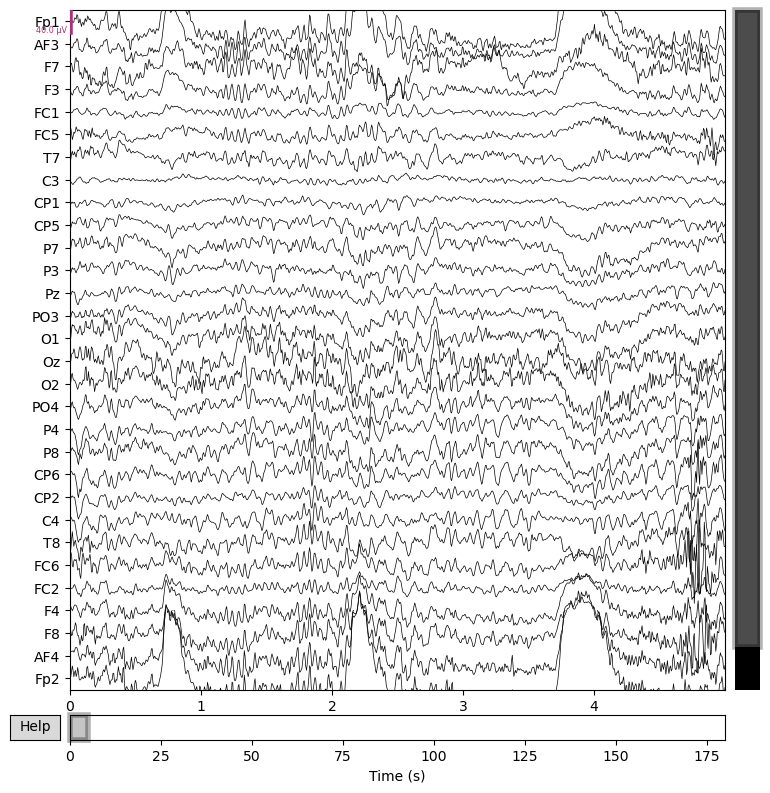

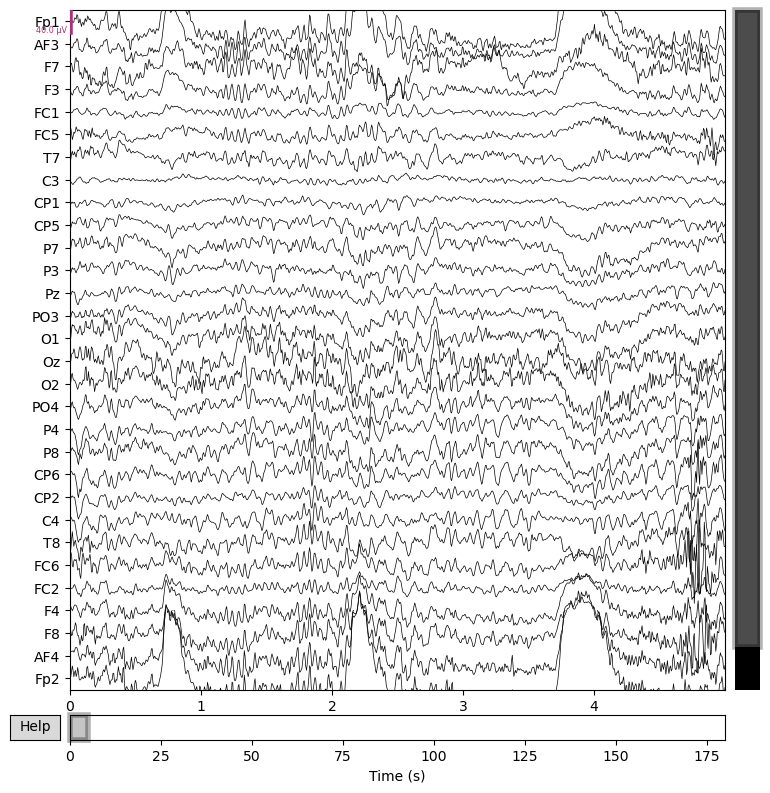

In [14]:
raw.plot(duration=5, n_channels=30)

In [15]:
raw = apply_ica(raw)

Fitting ICA to data using 32 channels (please be patient, this may take a while)
Selecting by number: 32 components
Fitting ICA took 10.4s.
Using EOG channels: Fp2, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 H

In [19]:
eeg_data = segment_data(raw)
print(f"Preprocessed EEG data shape: {eeg_data.shape}")

Not setting metadata
180 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 180 events and 513 original time points ...
0 bad epochs dropped
Preprocessed EEG data shape: (180, 32, 513)


In [20]:
# Trimming the last sample to get (180, 32, 512) shape
eeg_data = eeg_data[:, :, :512]
print(f"Trimmed EEG data shape: {eeg_data.shape}")

Trimmed EEG data shape: (180, 32, 512)


In [21]:
freq_bands = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 12),
    "beta": (13, 30),
    "gamma": (30, 48)
}

In [22]:
import mne
import numpy as np

def split_into_frequency_bands(eeg_data, sfreq, freq_bands):
    """
    eeg_data: ndarray (epochs, channels, time)
    sfreq: sampling frequency
    freq_bands: dictionary of frequency bands

    returns:
        band_signals: dict of band-limited EEG signals
    """

    band_signals = {}

    for band, (low, high) in freq_bands.items():
        # Apply band-pass filter
        band_data = mne.filter.filter_data(
            data=eeg_data,
            sfreq=sfreq,
            l_freq=low,
            h_freq=high,
            verbose=False
        )

        band_signals[band] = band_data

    return band_signals


In [23]:
sfreq = 512  # Hz

band_eeg = split_into_frequency_bands(eeg_data, sfreq, freq_bands)


C:\Users\enneh\AppData\Local\Temp\ipykernel_5528\313958705.py:18: RuntimeWarning: filter_length (1691) is longer than the signal (512), distortion is likely. Reduce filter length or filter a longer signal.
  band_data = mne.filter.filter_data(
C:\Users\enneh\AppData\Local\Temp\ipykernel_5528\313958705.py:18: RuntimeWarning: filter_length (845) is longer than the signal (512), distortion is likely. Reduce filter length or filter a longer signal.
  band_data = mne.filter.filter_data(
C:\Users\enneh\AppData\Local\Temp\ipykernel_5528\313958705.py:18: RuntimeWarning: filter_length (845) is longer than the signal (512), distortion is likely. Reduce filter length or filter a longer signal.
  band_data = mne.filter.filter_data(
C:\Users\enneh\AppData\Local\Temp\ipykernel_5528\313958705.py:18: RuntimeWarning: filter_length (521) is longer than the signal (512), distortion is likely. Reduce filter length or filter a longer signal.
  band_data = mne.filter.filter_data(


In [25]:
band_eeg["alpha"].shape  
   
   


(180, 32, 512)

In [26]:
band_eeg["beta"].shape

(180, 32, 512)

In [27]:
band_eeg["gamma"].shape

(180, 32, 512)

In [28]:
band_eeg["theta"].shape

(180, 32, 512)

In [29]:
band_eeg["delta"].shape

(180, 32, 512)